In [1]:
import os
from tqdm import tqdm
import pandas as pd

df = pd.read_csv("/project/lt200324-optmul/pluem/version_3/train_dataset_final.csv")
df

,Unnamed: 0,image_path,text,category
0,0,/project/lt200324-optmul/pluem/version_3/image...,"พ.ย. 12, 2069",date
1,1,/project/lt200324-optmul/pluem/version_3/image...,๒๖-September-๒๕๔๙,date
2,2,/project/lt200324-optmul/pluem/version_3/image...,2489-05-05,date
3,3,/project/lt200324-optmul/pluem/version_3/image...,15-09-63,date
4,4,/project/lt200324-optmul/pluem/version_3/image...,2592-18-10,date
...,...,...,...,...
40883716,40883716,/project/lt200324-optmul/pluem/version_3/image...,พันเรือตรีวรรณา สาริกาดิษ,name
40883717,40883717,/project/lt200324-optmul/pluem/version_3/image...,มุธิตา อัมพะผลิน,name
40883718,40883718,/project/lt200324-optmul/pluem/version_3/image...,พลเอก ฐานพัฒน์ สัมปันนานนท์,name
40883719,40883719,/project/lt200324-optmul/pluem/version_3/image...,พันตรีฟาฮาน่า ตัณฑสินธุ,name


In [2]:
# Model
ENCODER_MODEL_PATH = "/project/lt200324-optmul/pluem/model/trocr-base-handwritten"
DECODER_MODEL_PATH = "/project/lt200324-optmul/pluem/model/huggingface_electra-small-25000-no-grad-small"

In [ ]:
from transformers import (
    VisionEncoderDecoderModel,
    TrOCRProcessor,
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoConfig,
    AdamW,
    get_linear_schedule_with_warmup,
)

tokenizer = AutoTokenizer.from_pretrained(DECODER_MODEL_PATH)

In [ ]:
# Calculate token lengths
token_lengths = []

for text in tqdm(df['text']):
    tokens = tokenizer(text, return_tensors='pt')
    input_ids_length = len(tokens["input_ids"][0])
    token_lengths.append(input_ids_length)

# Add the lengths to the DataFrame
df['token_length'] = token_lengths

# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['token_length'], bins=30, kde=True)
plt.title('Distribution of Token Lengths')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.grid()
plt.show()

 12%|█▏        | 4783346/40883721 [11:40<1:33:23, 6442.00it/s] 

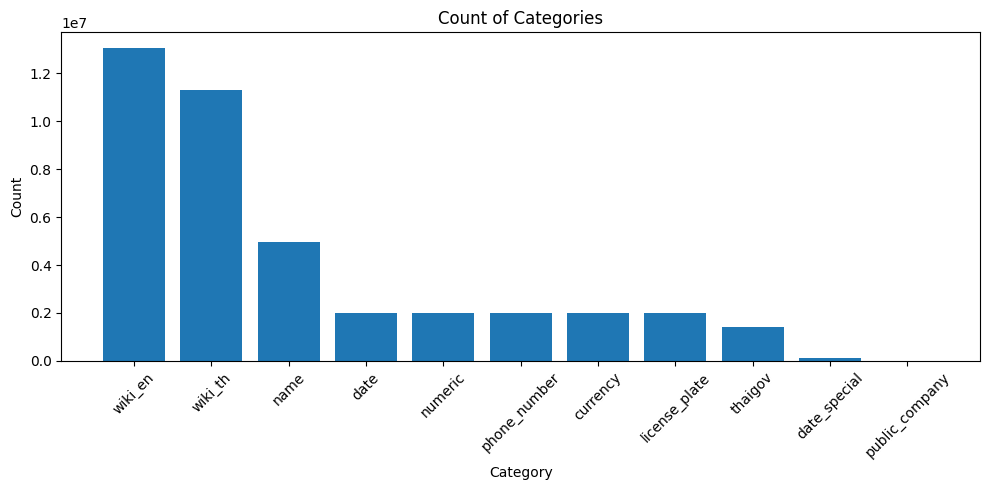

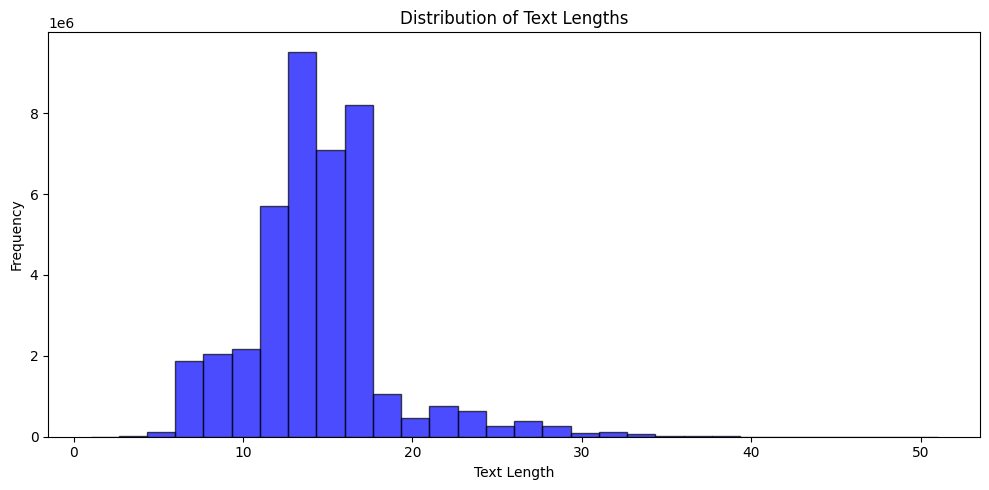

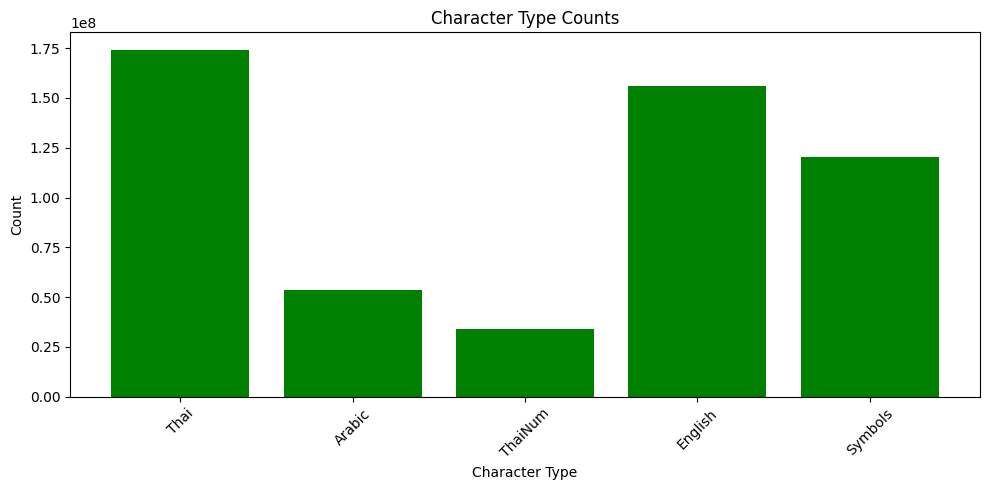

<Figure size 1000x500 with 0 Axes>

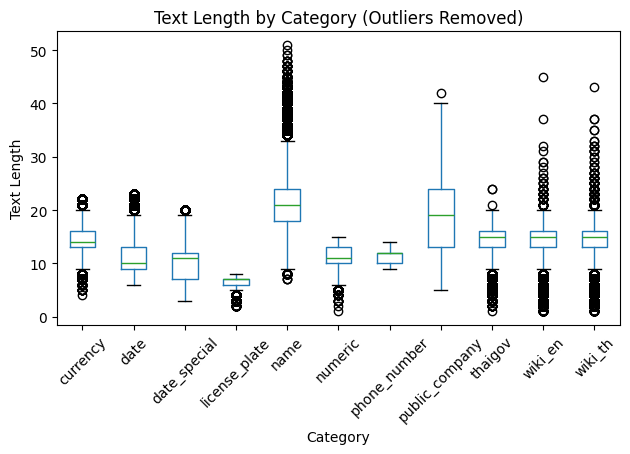

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import re

df['text_length'] = df['text'].apply(len)
df = df[df['text_length'] <= 60]

# 1. Category Count with Percentage
category_count = df['category'].value_counts()
total_count = category_count.sum()

plt.figure(figsize=(10, 5))
bars = plt.bar(category_count.index, category_count.values)

# Add percentage labels on the bars
for bar in bars:
    yval = bar.get_height()
    percentage = (yval / total_count) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{percentage:.1f}%', 
             ha='center', va='bottom')  # va='bottom' to place label above the bar

plt.title('Count of Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Text Length Count
plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Character Type Counts
def count_characters(text):
    thai_alphabet = len(re.findall(r'[ก-ฮ]', text))
    arabic_numerals = len(re.findall(r'[0-9]', text))
    thai_numerals = len(re.findall(r'[๐-๙]', text))
    english_alphabet = len(re.findall(r'[a-zA-Z]', text))
    symbols = len(re.findall(r'[^ก-ฮ0-9๐-๙a-zA-Z\s]', text))
    return thai_alphabet, arabic_numerals, thai_numerals, english_alphabet, symbols

character_counts = df['text'].apply(count_characters)
character_counts_df = pd.DataFrame(character_counts.tolist(), columns=['Thai', 'Arabic', 'ThaiNum', 'English', 'Symbols'])

# Summarize the counts
character_summary = character_counts_df.sum()

plt.figure(figsize=(10, 5))
plt.bar(character_summary.index, character_summary.values, color='green')
plt.title('Character Type Counts')
plt.xlabel('Character Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Box Plot of Text Length by Category
plt.figure(figsize=(10, 5))
df.boxplot(column='text_length', by='category', grid=False)
plt.title('Text Length by Category (Outliers Removed)')
plt.suptitle('')  # Suppress the default title
plt.xlabel('Category')
plt.ylabel('Text Length')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

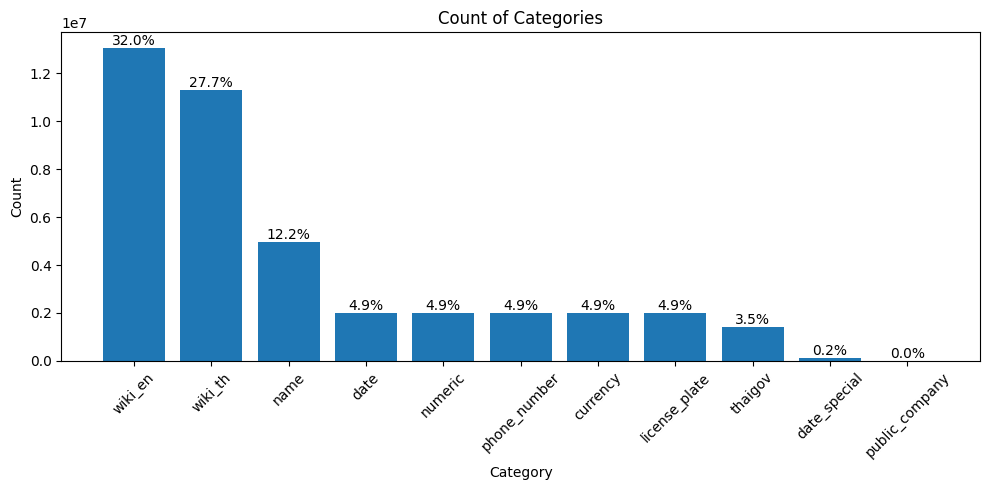

In [5]:
# 1. Category Count with Percentage
category_count = df['category'].value_counts()
total_count = category_count.sum()

plt.figure(figsize=(10, 5))
bars = plt.bar(category_count.index, category_count.values)

# Add percentage labels on the bars
for bar in bars:
    yval = bar.get_height()
    percentage = (yval / total_count) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{percentage:.1f}%', 
             ha='center', va='bottom')  # va='bottom' to place label above the bar

plt.title('Count of Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

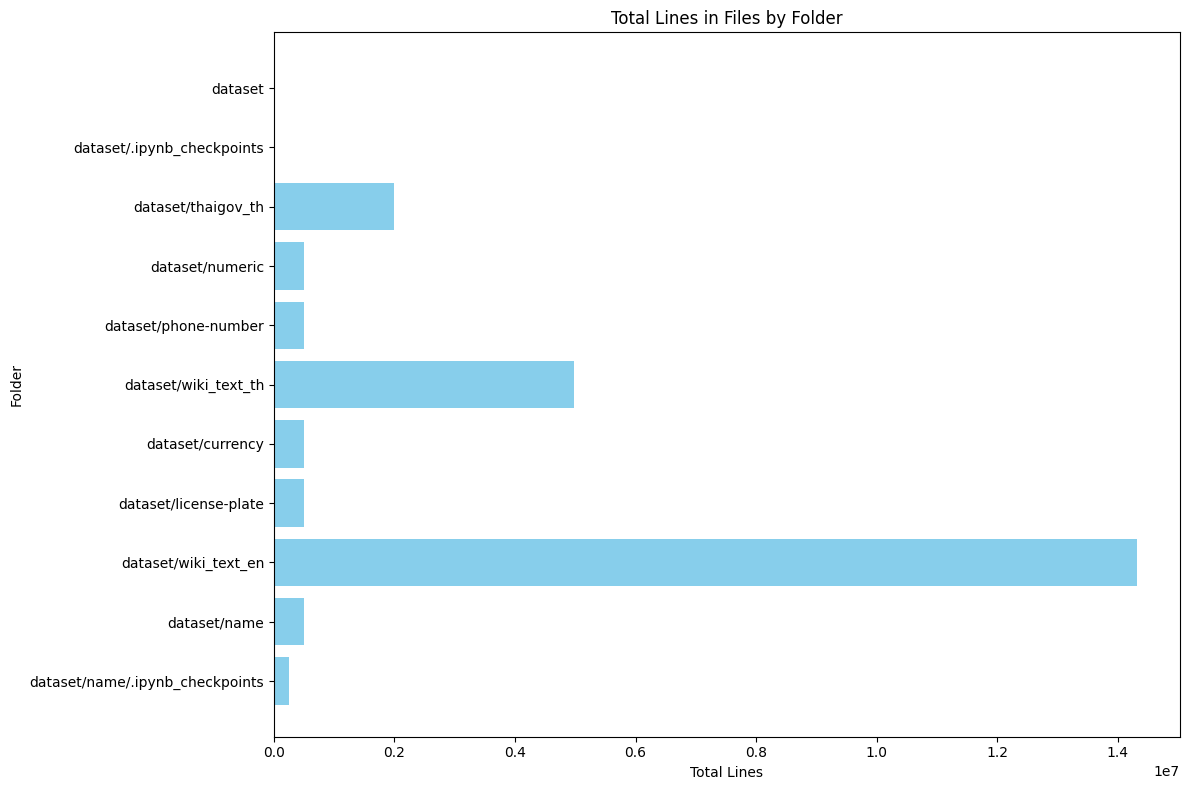

In [5]:
def plot_line_counts(folder_line_counts):
    """Plots the line counts for each folder."""
    folders = list(folder_line_counts.keys())
    line_counts = list(folder_line_counts.values())
    
    plt.figure(figsize=(12, 8))
    plt.barh(folders, line_counts, color='skyblue')
    plt.xlabel('Total Lines')
    plt.ylabel('Folder')
    plt.title('Total Lines in Files by Folder')
    plt.gca().invert_yaxis()  # Invert y-axis to have the folder with the highest count at the top
    plt.tight_layout()
    plt.show()

# Plot the results
plot_line_counts(line_counts)

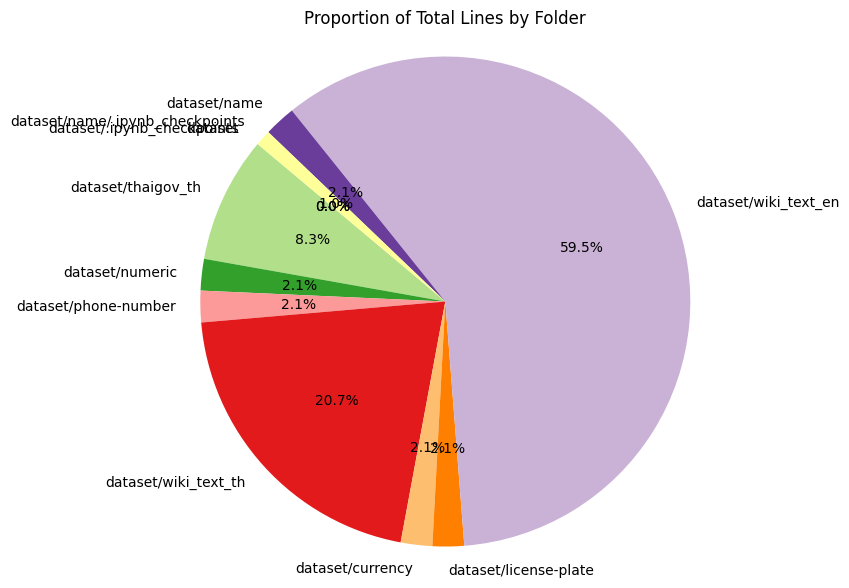

In [6]:
def plot_pie_chart(folder_line_counts):
    """Plots a pie chart of line counts for each folder."""
    if not folder_line_counts:
        print("No data to plot.")
        return

    folders = list(folder_line_counts.keys())
    line_counts = list(folder_line_counts.values())
    
    plt.figure(figsize=(10, 7))
    plt.pie(line_counts, labels=folders, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired(range(len(folders))))
    plt.title('Proportion of Total Lines by Folder')
    plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
    plt.show()

# Plot the results
plot_pie_chart(line_counts)

100%|██████████| 3/3 [00:14<00:00,  4.82s/it]

{'Thai': 64436408, 'English': 888228, 'Number': 1280759, 'Symbol': 719656}


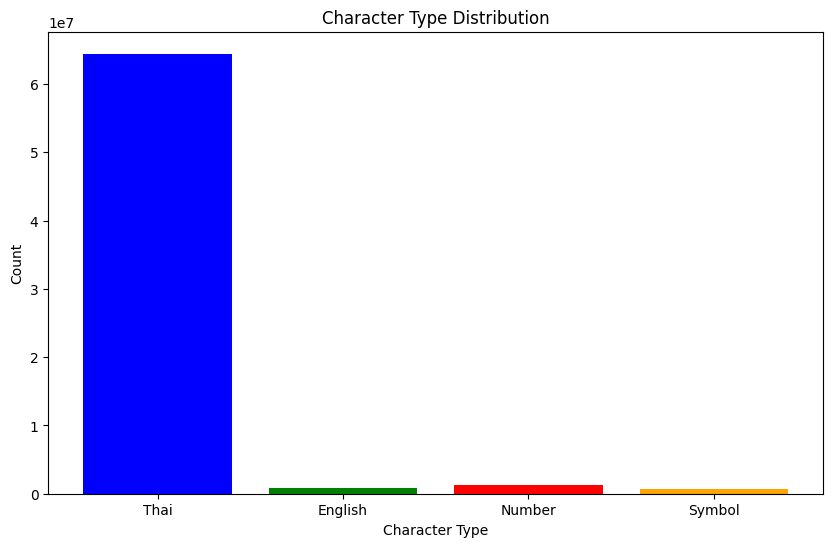

In [9]:
import re
from collections import defaultdict
import matplotlib.pyplot as plt

# Initialize counters
counters = {
    'Thai': 0,
    'English': 0,
    'Number': 0,
    'Symbol': 0
}

# Define Unicode ranges for Thai, English, and Numbers
thai_range = re.compile(r'[\u0E00-\u0E7F]')
english_range = re.compile(r'[A-Za-z]')
number_range = re.compile(r'[0-9]')
symbol_range = re.compile(r'[^\u0E00-\u0E7F A-Za-z0-9\s]')  # Symbols include punctuation, etc.

# Open and process the file in chunks
def process_file(filename):
    with open(filename, 'r', encoding='utf-8') as file:
        for line in file:
            global counters
            counters['Thai'] += len(thai_range.findall(line))
            counters['English'] += len(english_range.findall(line))
            counters['Number'] += len(number_range.findall(line))
            counters['Symbol'] += len(symbol_range.findall(line))

def process_directory(directory):
    """Process all files in the specified directory and subdirectories."""
    for root, dirs, files in os.walk(directory):
        for filename in tqdm(files):
            file_path = os.path.join(root, filename)
            if os.path.isfile(file_path):
                process_file(file_path)

# Define the directory containing the files
directory = 'dataset/wiki_text_th'  # Replace with your directory path

# Process all files in the directory
process_directory(directory)

# Output the results
print(counters)

# Visualization
categories = list(counters.keys())
values = list(counters.values())

plt.figure(figsize=(10, 6))
plt.bar(categories, values, color=['blue', 'green', 'red', 'orange'])
plt.xlabel('Character Type')
plt.ylabel('Count')
plt.title('Character Type Distribution')
plt.show()

In [10]:
def compute_percentages(counter_dict):
    """Computes the percentage of each category relative to the total count."""
    total = sum(counter_dict.values())
    percentages = {k: (v / total) * 100 for k, v in counter_dict.items()}
    return percentages

# Compute percentages
percentages = compute_percentages(counters)

# Output the percentages
for category, percentage in percentages.items():
    print(f"{category}: {percentage:.2f}%")

Thai: 95.71%
English: 1.32%
Number: 1.90%
Symbol: 1.07%
